#1. Importando Dataset

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_json('TelecomX_Data.json')
for coluna in df.columns[2:]:
   df = df.drop(columns=[coluna]).join(pd.json_normalize(df[coluna]))

#2. Tratando as Inconsistências

In [16]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df = df.dropna()

df = df[df['Churn'].str.strip() != '']
df['MultipleLines'] = df['MultipleLines'].str.replace(r"^No.*", "No", regex=True)
for coluna in df.columns[10:16]:
  df[coluna] = df[coluna].str.replace(r"^No.*", "No", regex=True)

#3. Criando Novas Tabelas

In [17]:
df['Contas_Diarias'] = df['Charges.Monthly'] / 30

#4. Análise Descritiva

In [18]:
analise_geral = df.groupby("Churn")[["tenure", "Charges.Monthly", "Charges.Total", "Contas_Diarias"]].agg(["mean", "median", "std"])

#5. Distribuição da Evasão

In [39]:
def calcular_cancelamentos_colunas(colunas):
  resultados = []
  for coluna in colunas:
    tabela = pd.crosstab(df[coluna], df["Churn"], normalize="index") * 100

    if "Yes" in tabela.index:
      linha = tabela.loc["Yes"]
      linha.name = coluna
      resultados.append(linha)

  return pd.DataFrame(resultados)

##a. Cálculos

In [43]:
percentual_cancelamento = df["Churn"].value_counts(normalize=True) * 100
cancelamentos_contrato = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
cancelamentos_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
cancelamentos_genero = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

servicos = df.columns[7:9].append(df.columns[10:16])
perfis = df.columns[3:6]
cancelamentos_servicos = calcular_cancelamentos_colunas(servicos)
cancelamentos_perfis = calcular_cancelamentos_colunas(perfis)
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


##b. Gráficos

###1. Percentual de Evasão

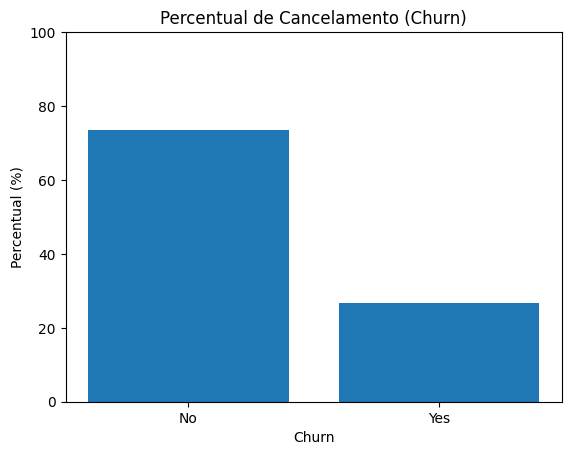

In [14]:
plt.figure()

plt.bar(
    percentual_cancelamento.index,
    percentual_cancelamento.values
)

plt.title("Percentual de Cancelamento (Churn)")
plt.xlabel("Churn")
plt.ylabel("Percentual (%)")

plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

###2. Evasão por Tipo de Contrato

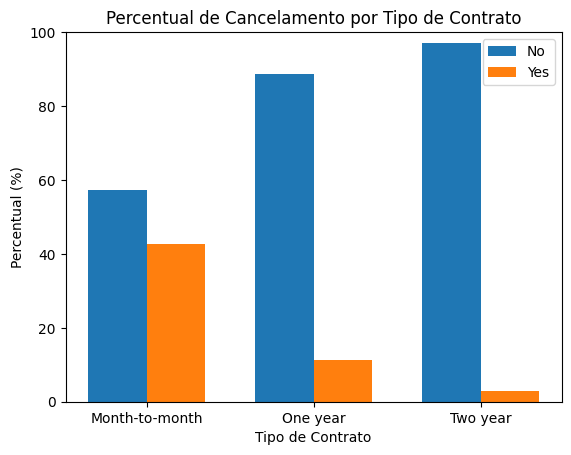

In [20]:
x = np.arange(len(cancelamentos_contrato.index))
width = 0.35

plt.figure()

plt.bar(
    x - width/2,
    cancelamentos_contrato["No"],
    width,
    label="No"
)

plt.bar(
    x + width/2,
    cancelamentos_contrato["Yes"],
    width,
    label="Yes"
)

plt.xticks(x, cancelamentos_contrato.index, rotation=0)
plt.ylabel("Percentual (%)")
plt.xlabel("Tipo de Contrato")
plt.title("Percentual de Cancelamento por Tipo de Contrato")
plt.ylim(0, 100)

plt.legend()
plt.show()

###3. Evasão por Serviço

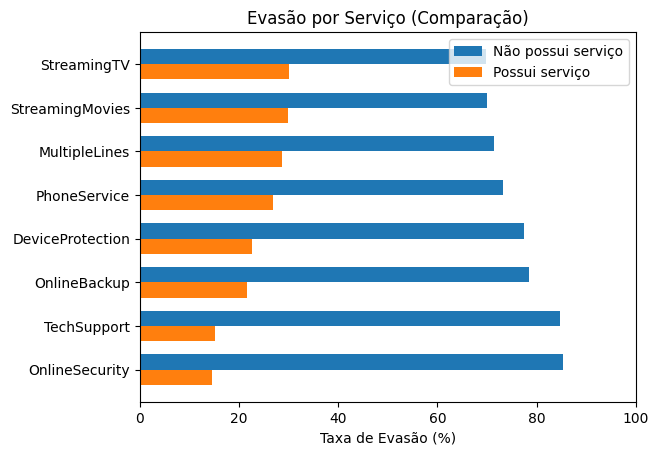

In [41]:
cancelamentos_servicos_sorted = cancelamentos_servicos.sort_values(by="Yes", ascending=False)

x = np.arange(len(cancelamentos_servicos_sorted.index))
width = 0.35

plt.figure()

plt.barh(
    x - width/2,
    cancelamentos_servicos_sorted["No"],
    width,
    label="Não possui serviço"
)

plt.barh(
    x + width/2,
    cancelamentos_servicos_sorted["Yes"],
    width,
    label="Possui serviço"
)

plt.yticks(x, cancelamentos_servicos_sorted.index)
plt.xlabel("Taxa de Evasão (%)")
plt.title("Evasão por Serviço (Comparação)")
plt.xlim(0, 100)

plt.legend()
plt.gca().invert_yaxis()

plt.show()

###4. Evasão por Serviço de internet

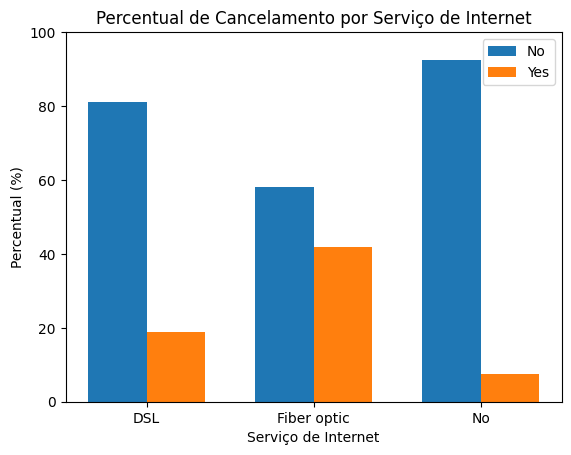

In [26]:
x = np.arange(len(cancelamentos_internet.index))
width = 0.35

plt.figure()

plt.bar(
    x - width/2,
    cancelamentos_internet["No"],
    width,
    label="No"
)

plt.bar(
    x + width/2,
    cancelamentos_internet["Yes"],
    width,
    label="Yes"
)

plt.xticks(x, cancelamentos_internet.index, rotation=0)
plt.ylabel("Percentual (%)")
plt.xlabel("Serviço de Internet")
plt.title("Percentual de Cancelamento por Serviço de Internet")
plt.ylim(0, 100)

plt.legend()
plt.show()

###5. Evasão por Perfil

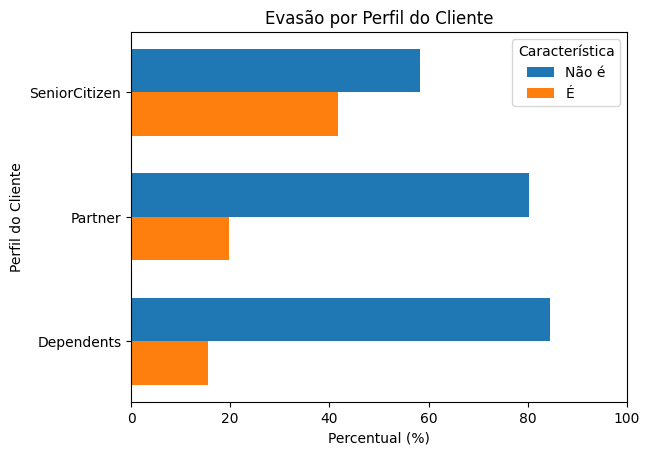

In [44]:
import matplotlib.pyplot as plt
import numpy as np

cancelamentos_perfis_sorted = cancelamentos_perfis.sort_values(by="Yes", ascending=False)

x = np.arange(len(cancelamentos_perfis_sorted.index))
width = 0.35

plt.figure()

plt.barh(
    x - width/2,
    cancelamentos_perfis_sorted["No"],
    width,
    label="Não é"
)

plt.barh(
    x + width/2,
    cancelamentos_perfis_sorted["Yes"],
    width,
    label="É"
)

plt.yticks(x, cancelamentos_perfis_sorted.index)
plt.xlabel("Percentual (%)")
plt.ylabel("Perfil do Cliente")
plt.title("Evasão por Perfil do Cliente")
plt.xlim(0, 100)

plt.legend(title="Característica")
plt.gca().invert_yaxis()

plt.show()